### This notebook computes "VSB6. Theoretical hydroelectric potential" indicator for the 27 basins of IKI Project

**Spanish:** Potencial hidroelectrico teorico

**Created:** 10/10/2025 by Sophia Bakar (sbakar@rti.org) 
 
**Assumptions:** 

**Notes:** Calculated the hydraulic head in ArcGIS following these steps
1. reprojected DEM and flowlines to EPSG:32718
2. Used "generate points along lines" tool to create points along the flowline (100m apart). Output is a point layer with points along each flowline  
3. Used "Extract values to points" tool to get elevation at each point from DEM. Outputs points with a new field containing elevation
4. Calculated head (H) for each COMID by getting difference between max and min elevation along each flowline
5. Exported the results as a table with COMID and H_m columns

In [ ]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt
from shapely.geometry import LineString, Point
import rasterio
import re
import yaml
from pathlib import Path

In [ ]:
# set master path for input data from config file

config_path = Path("../../config.yaml")

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

master_path = Path(config["master_path"])

In [ ]:
subbasins_shapefile = master_path / "Modelacion" / "Grupos_Modelacion" / "GIS_WaterALLOC_General" / "Peru_AHD_with_districts.shp"
db_path = master_path / "Indicadores" / "BD_RiesgoClimatico_IKI.db"
wateralloc_db = master_path / "Modelacion" / "Grupos_Modelacion" / "Resultados" / "BalanceHidrico.sqlite"
catchments_shapefile = master_path / "Modelacion" / "Grupos_Modelacion" / "GIS_WaterALLOC_General" / "Peru_catchment_modeling.shp"
flowlines_shapefile = master_path / "Modelacion" / "Grupos_Modelacion" / "GIS_WaterALLOC_General" / "Peru_flowlines_modeling.shp"   
hydraulic_head = master_path / "Indicadores" / "HydraulicHead.csv"

In [3]:
# set up indicator ID and get scenarios from database
IndID= 306 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
conn = sqlite3.connect(db_path)

scenarios_df = pd.read_sql_query(
    """
    SELECT ScnID, ScnName
    FROM ScnMod
    """,
    conn
)

conn.close()

# For now: only baseline and first future
scenario_ids = scenarios_df.loc[
    scenarios_df['ScnID'].isin([1, 2]), 'ScnID'
].tolist()

# for all scenarios:
# scenario_ids = scenarios_df['ScnID'].tolist()

In [4]:
## check what scenarios are available in the WaterALLOC database
# Connect to WaterALLOC database
conn_wa = sqlite3.connect(wateralloc_db)

# Query available scenarios
scenarios_query = """
SELECT DISTINCT Scenario
FROM Scenarios
ORDER BY Scenario
"""

wa_scenarios_df = pd.read_sql_query(scenarios_query, conn_wa)

print("Available scenarios in WaterALLOC DB:")
for s in wa_scenarios_df["Scenario"]:
    print(f" - {s}")



Available scenarios in WaterALLOC DB:
 - CC_CMIP6_85_2050
 - Linea_Base_2020
 - Linea_Base_2020_Embalses


In [5]:
# Extract year from scenario name and sort by year
def extract_year(name):
    match = re.search(r'\d{4}$', name)
    if match:
        return int(match.group())
    else:
        return np.nan  # just in case

wa_scenarios_df['Year'] = wa_scenarios_df['Scenario'].apply(extract_year)
wa_scenarios_df = wa_scenarios_df.sort_values('Year').reset_index(drop=True)

# Assign dynamic ScnID based on year order
wa_scenarios_df['ScnID_dynamic'] = np.arange(1, len(wa_scenarios_df) + 1)

# Map dynamic ScnID -> scenario name
scenario_mapping = dict(zip(wa_scenarios_df['ScnID_dynamic'], wa_scenarios_df['Scenario']))

print("\nDynamic scenario mapping (ScnID -> WaterALLOC Scenario Name):")
for scn_id, scn_name in scenario_mapping.items():
    print(f" - ScnID {scn_id} -> {scn_name}")


Dynamic scenario mapping (ScnID -> WaterALLOC Scenario Name):
 - ScnID 1 -> Linea_Base_2020
 - ScnID 2 -> CC_CMIP6_85_2050
 - ScnID 3 -> Linea_Base_2020_Embalses


In [7]:
# get monthly average flow from WaterALLOC database for each scenario
# (Inflow + Local Flow - Demand)
flow_all = []

conn_wa = sqlite3.connect(wateralloc_db)

for scn_id_dynamic, scenario_name in scenario_mapping.items():
    print(f"\nProcessing scenario: {scenario_name} (ScnID={scn_id_dynamic})")

    query_flow = """
    SELECT 
        a.comid AS COMID,
        AVG(
            a.[Oferta Entrada] 
          + a.[Oferta Local Sup] 
          - a.[Dem Local Sup]
        ) AS Caudal_Medio,
        COUNT(*) AS n_months
    FROM "WAMSS_Balance por COMID (+Indice de estres)" AS a
    JOIN WAMMS_RunsInfo AS b 
        ON a.RunID = b.RunID
    JOIN Scenarios AS c 
        ON c.ScnID = b.ScnID
    WHERE c.Scenario = ?
    GROUP BY a.comid
    """

    flow_df = pd.read_sql_query(query_flow, conn_wa, params=(scenario_name,))

    # Add dynamic ScnID column
    flow_df['ScnID_dynamic'] = scn_id_dynamic

    flow_all.append(flow_df)

conn_wa.close()

flow_all_df = pd.concat(flow_all, ignore_index=True)
flow_all_df = flow_all_df[flow_all_df['COMID'].notna()].copy()


Processing scenario: Linea_Base_2020 (ScnID=1)

Processing scenario: CC_CMIP6_85_2050 (ScnID=2)

Processing scenario: Linea_Base_2020_Embalses (ScnID=3)


In [ ]:
# read in input data
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')
catchments_gdf = gpd.read_file(catchments_shapefile).to_crs('EPSG:32718')
flowlines_gdf = gpd.read_file(flowlines_shapefile).to_crs('EPSG:32718')
head_df = pd.read_csv(hydraulic_head)

In [9]:
# function to compute hydroelectric potential (PL) 
def compute_PL(Q, H, g=9.81):
    return g * Q * H

In [10]:
# Base COMIDs from subbasins
base_comids = subbasins_gdf[['COMID']].drop_duplicates()

# Explicit scenario table (use the same scenario_ids you already defined)
base_scenarios = pd.DataFrame({'ScnID_dynamic': scenario_ids})

# Cartesian product: every COMID gets every scenario
base_index = base_comids.merge(base_scenarios, how='cross')

# Merge flow (scenario-dependent)
pl_results = base_index.merge(
    flow_all_df,
    on=['COMID', 'ScnID_dynamic'],
    how='left'
)

# Merge hydraulic head (scenario-independent)
pl_results = pl_results.merge(
    head_df,
    on='COMID',
    how='left'
)

pl_results['H_m'] = pl_results['H_m'].astype(float)

pl_results['PL_W'] = np.where(
    pl_results[['Caudal_Medio', 'H_m']].notna().all(axis=1),
    compute_PL(pl_results['Caudal_Medio'], pl_results['H_m']),
    np.nan
)

pl_results = pl_results[
    ['COMID', 'ScnID_dynamic', 'Caudal_Medio', 'H_m', 'PL_W']
]

# convert PL_W to MW
pl_results['PL_MW'] = pl_results['PL_W'] / 1e6

In [11]:
# Merge PL results with subbasins geometries for plotting
subbasins_plot_gdf = subbasins_gdf[['COMID', 'geometry']].merge(
    pl_results,
    on='COMID',
    how='left'
)

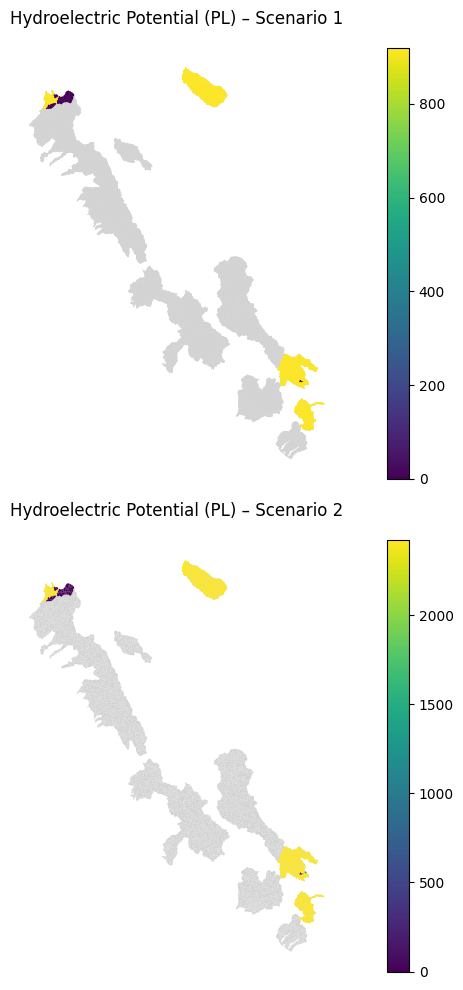

In [12]:
# List of scenarios (drop NaNs just in case)
scenarios = sorted(subbasins_plot_gdf['ScnID_dynamic'].dropna().unique())
n_scenarios = len(scenarios)

fig, axes = plt.subplots(n_scenarios, 1,figsize=(10, 5 * n_scenarios))

if n_scenarios == 1:
    axes = [axes]

for i, scn_id in enumerate(scenarios):
    ax = axes[i]

    data = subbasins_plot_gdf[subbasins_plot_gdf['ScnID_dynamic'] == scn_id]
    data.plot(ax=ax,color='lightgrey',edgecolor='none')

    data_valid = data[data['PL_W'].notna()]

    if not data_valid.empty:
        vmin = data_valid['PL_MW'].quantile(0.02)
        vmax = data_valid['PL_MW'].quantile(0.98)
        data_valid.plot(
            column='PL_W',
            ax=ax,
            cmap='viridis',
            legend=True,
            vmin=vmin,
            vmax=vmax
        )

    ax.set_title(f"Hydroelectric Potential (PL) – Scenario {scn_id}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [15]:
pl_results_unique = pl_results.drop_duplicates(subset=['COMID', 'ScnID_dynamic']).reset_index(drop=True)

In [16]:
insert_data = pl_results_unique.copy()
value_column = 'PL_MW'

# Connect to SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

rows_to_insert = []

for _, row in insert_data.iterrows():
    scn_id = row['ScnID_dynamic']
    comid = row['COMID']
    value = row[value_column]

    # Skip rows without scenario or value
    if pd.isna(scn_id) or pd.isna(value):
        continue

    rows_to_insert.append((
        int(scn_id),
        IndID,
        int(comid),
        float(value)
    ))

# Insert query
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""

In [17]:
# Check indicator limits
indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, 'Min']
ind_max = indicator_limits.loc[0, 'Max']

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

# Print stats by scenario
value_stats_by_scenario = (
    pl_results_unique
    .groupby('ScnID_dynamic')['PL_MW']
    .agg(['min', 'max', 'count'])
    .reset_index()
)

print("\n=== PL_W values by scenario ===")
print(value_stats_by_scenario)

# Check for duplicates in rows_to_insert
df_check = pd.DataFrame(
    rows_to_insert,
    columns=['ScnID', 'IndID', 'COMID', 'Value']
)

duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])

print("\nDuplicates in rows_to_insert (should be empty):")
print(df_check[duplicates])


Indicator 306  Min: 0, Max: 45000000000

=== PL_W values by scenario ===
   ScnID_dynamic  min           max  count
0              1  0.0  27582.267254    538
1              2  0.0  44367.525229    538

Duplicates in rows_to_insert (should be empty):
Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [18]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()